In [21]:
import numpy as np
import jax
import jax.numpy as jnp
from jax import jacfwd
from jax import jit
from jax import vmap
from jax import jacfwd
import pandas as pd
import matplotlib.pyplot as plt
import corner
import seaborn as sns
import emcee
from matplotlib.lines import Line2D

In [2]:
G = 2.959122082855911e-4 # [AU^3 / (Msun * day^2)]
ML = 0.5
mu = G * ML
tref = 0

In [3]:
@jit
def kepler_to_rv_inertial_frame(a, e, i, Om, om, t_peri):
    n = jnp.sqrt(mu / a**3)
    M = n * (tref - t_peri)

    def kepler_eq(E):
        return E - e * jnp.sin(E) - M
    E = M
    for _ in range(8):
        E = E - kepler_eq(E) / (1 - e * jnp.cos(E))

    nu = 2 * jnp.arctan2(jnp.sqrt(1 + e) * jnp.sin(E / 2),
                         jnp.sqrt(1 - e) * jnp.cos(E / 2))

    r_0 = a * (1 - e * jnp.cos(E))
    r_pf = jnp.array([r_0 * jnp.cos(nu),
                      r_0 * jnp.sin(nu),
                      0.0])

    v_pf = (a*n / r_0) * jnp.array([
        -jnp.sin(E),
         jnp.sqrt(1 - e**2) * jnp.cos(E),
         0.0
    ])

    cO, sO = jnp.cos(Om), jnp.sin(Om)
    co, so = jnp.cos(om), jnp.sin(om)
    ci, si = jnp.cos(i), jnp.sin(i)

    Rz_Om = jnp.array([[ cO, -sO, 0.0],
                       [ sO,  cO, 0.0],
                       [0.0,  0.0, 1.0]])

    Rx_i  = jnp.array([[1.0, 0.0, 0.0],
                       [0.0,  ci, -si],
                       [0.0,  si,  ci]])

    Rz_om = jnp.array([[ co, -so, 0.0],
                       [ so,  co, 0.0],
                       [0.0,  0.0, 1.0]])

    R = Rz_Om @ Rx_i @ Rz_om

    r = R @ r_pf
    v = R @ v_pf

    return jnp.concatenate([r, v])

@jit
def kepler_to_rv_rotating_frame(a, e, i, om, t_peri):

    y = kepler_to_rv_inertial_frame(a, e, i, 0., om, t_peri)
    r, v = y[:3], y[3:]

    theta = jnp.arctan2(r[1], r[0])
    Rz_rot = jnp.array([[ jnp.cos(-theta), -jnp.sin(-theta), 0.0],
                        [ jnp.sin(-theta),  jnp.cos(-theta), 0.0],
                        [ 0.0,              0.0,             1.0]])

    r_rot = Rz_rot @ r
    v_rot = Rz_rot @ v

    idx = jnp.array([0, 2])

    return jnp.concatenate([r_rot[idx], v_rot])

@jit
def kepler_to_rv_alpha(a, e, i, OmNE, om, t_peri, phi_mu =0.5):

    q_phys = kepler_to_rv_inertial_frame(a, e, i, OmNE, om, t_peri) #OmNEで計算しているので、物理的に意味がある。
    r_phys, v_phys = q_phys [:3], q_phys [3:]
    
    
    #binary axix 座標の定義
    z_hat = jnp.array([0.0, 0.0, 1.0]) # LOS 
    p = r_phys - jnp.dot(r_phys, z_hat) * z_hat  #天球面へ射影したr_physベクトル
    p_norm = jnp.linalg.norm(p)
    x0 = p / p_norm
    y0 = jnp.cross(z_hat, x0)
    y0 = y0 / (jnp.linalg.norm(y0))   
    
    h = jnp.cross(
        jnp.array([p_norm, 0, r_phys[2]]),#マイクロレンズ座標で測ったrとvの外積。
        jnp.array([
            jnp.dot(v_phys, x0),
            jnp.dot(v_phys, y0),
            jnp.dot(v_phys, z_hat)
        ])
    ) # angular momentum in binary axis  coordinate 
    z_orb = h / jnp.linalg.norm(h)
    Om0 = jnp.arctan2(z_orb[0], -z_orb[1]) #gapmoe論 式(23)
    alpha = Om0 + phi_mu  - OmNE #gapmoe論 式(24)
    
    theta = jnp.arctan2(r_phys[1], r_phys[0])
    Rz_rot = jnp.array([[ jnp.cos(-theta), -jnp.sin(-theta), 0.0],
                        [ jnp.sin(-theta),  jnp.cos(-theta), 0.0],
                        [ 0.0,              0.0,             1.0]])

    r_rot = Rz_rot @ r_phys
    v_rot = Rz_rot @ v_phys

    return jnp.array([r_rot[0],alpha,r_rot[2], v_rot[0], v_rot[1], v_rot[2]])

In [4]:
@jit
def rv_to_kepler(rx,ry,rz,vx,vy,vz):
    r = jnp.array([rx,ry,rz])
    v = jnp.array([vx,vy,vz])
    eps = jnp.dot(v,v)/2 - mu/jnp.sqrt(jnp.dot(r,r))
    a = -mu/(2*eps)
    
    h = jnp.cross(r,v)
    A = jnp.cross(v,h) / (mu) - r / jnp.sqrt(jnp.dot(r,r))
    e = jnp.sqrt(jnp.dot(A,A))
    
    z = h / jnp.sqrt(jnp.dot(h,h))
    x = A / e
    y = jnp.cross(z,x)
    
    cos_i = z[2]
    sin_i = jnp.sqrt(1 - cos_i**2)
    i = jnp.arctan2(sin_i,cos_i)
    
    sin_Om0, cos_Om0 = z[0] / sin_i, - z[1] / sin_i
    Om0 = jnp.arctan2(sin_Om0, cos_Om0)
    
    sin_om, cos_om = x[2] / sin_i, y[2] / sin_i
    om = jnp.arctan2(sin_om, cos_om)
    
    cos_nu = jnp.dot(r,x)/jnp.sqrt(jnp.dot(r,r))
    sin_nu = jnp.dot(r,y)/jnp.sqrt(jnp.dot(r,r))
    nu = jnp.arctan2(sin_nu,cos_nu)
    
    denom = 1.0 + e * jnp.cos(nu)
    cosE = (e + jnp.cos(nu)) / denom
    sinE = (jnp.sqrt(1.0 - e**2) * jnp.sin(nu)) / denom
    E = jnp.arctan2(sinE, cosE)   
    Mano = E - e * jnp.sin(E)
    n = jnp.sqrt(mu / a**3)
    t_peri = tref - Mano / n

    return  jnp.array([jnp.log10(a), e, cos_i, Om0, om, Mano])

@jit
def rv_to_kepler_rot(rx,rz,vx,vy,vz):
    ry = 0
    r = jnp.array([rx,ry,rz])
    v = jnp.array([vx,vy,vz])
    eps = jnp.dot(v,v)/2 - mu/jnp.sqrt(jnp.dot(r,r))
    a = -mu/(2*eps)
    
    h = jnp.cross(r,v)
    A = jnp.cross(v,h) / (mu) - r / jnp.sqrt(jnp.dot(r,r))
    e = jnp.sqrt(jnp.dot(A,A))
    
    z = h / jnp.sqrt(jnp.dot(h,h))
    x = A / e
    y = jnp.cross(z,x)
    
    cos_i = z[2]
    sin_i = jnp.sqrt(1 - cos_i**2)
    i = jnp.arctan2(sin_i,cos_i)
    
    sin_Om0, cos_Om0 = z[0] / sin_i, - z[1] / sin_i
    Om0 = jnp.arctan2(sin_Om0, cos_Om0)
    
    sin_om, cos_om = x[2] / sin_i, y[2] / sin_i
    om = jnp.arctan2(sin_om, cos_om)
    
    cos_nu = jnp.dot(r,x)/jnp.sqrt(jnp.dot(r,r))
    sin_nu = jnp.dot(r,y)/jnp.sqrt(jnp.dot(r,r))
    nu = jnp.arctan2(sin_nu,cos_nu)
    
    denom = 1.0 + e * jnp.cos(nu)
    cosE = (e + jnp.cos(nu)) / denom
    sinE = (jnp.sqrt(1.0 - e**2) * jnp.sin(nu)) / denom
    E = jnp.arctan2(sinE, cosE)   
    Mano = E - e * jnp.sin(E)
    n = jnp.sqrt(mu / a**3)
    t_peri = tref - Mano / n

    return  jnp.array([jnp.log10(a), e, cos_i, om, Mano])

In [5]:
a, e, i, Om, om, t_peri = 1.0, 0.2, jnp.deg2rad(10.0), jnp.deg2rad(85.0), jnp.deg2rad(45.0), -20.0

rv_inertial = kepler_to_rv_inertial_frame(a, e, i, Om, om, t_peri)
r_inertial, v_inertial = rv_inertial[:3], rv_inertial[3:]

jac_inertial = jax.jacfwd(kepler_to_rv_inertial_frame, argnums=(0,1,2,3,4,5))
J_inertial = jnp.stack(jac_inertial(a, e, i, Om, om, t_peri), axis=1)
sign,logdetJ_inertial = jnp.linalg.slogdet(J_inertial)
print("Inertial frame      det(J):", logdetJ_inertial)

jac_rot = jax.jacfwd(kepler_to_rv_rotating_frame, argnums=(0,1,2,3,4))

J_rot = jnp.stack(jac_rot(a, e, i,  om, t_peri), axis=1)
sin, logdetJ_rot = jnp.linalg.slogdet(J_rot)
print("Rotating frame   det(J):", logdetJ_rot)

jac_alpha = jax.jacfwd(kepler_to_rv_alpha, argnums=(0,1,2,3,4,5))
J_alpha = jnp.stack(jac_alpha(a, e, i,  Om ,om, t_peri), axis=1)
sin, logdetJ_alpha = jnp.linalg.slogdet(J_alpha)
print("Rotating frame with alpha  det(J):", logdetJ_alpha)

print(logdetJ_inertial-logdetJ_rot, jnp.log(jnp.linalg.norm(r_inertial[:2])))

Inertial frame      det(J): -21.025896
Rotating frame   det(J): -20.801292
Rotating frame with alpha  det(J): -20.801292
-0.22460365 -0.22460298


In [6]:
key = jax.random.PRNGKey(42)
key, k_a, k_e, k_i, k_Om, k_om, k_M = jax.random.split(key, 7)
N = 20000

log_a = jax.random.uniform(k_a, (N,), minval=jnp.log(0.1), maxval=jnp.log(100))
a = jnp.exp(log_a)
e = jax.random.uniform(k_e, (N,), minval=0.0, maxval=0.99) 
cosi = jax.random.uniform(k_i, (N,), minval=-1, maxval=1)
i = jnp.arccos(cosi)
Om = jax.random.uniform(k_Om, (N,), minval=0.0, maxval=2*jnp.pi)
om = jax.random.uniform(k_om, (N,), minval=0.0, maxval=2*jnp.pi)
M = jax.random.uniform(k_M, (N,), minval=-jnp.pi, maxval=jnp.pi)
n = jnp.sqrt(mu / a**3)
t_peri = tref - M / n

rv_rot = jax.vmap(kepler_to_rv_rotating_frame)(a, e, i, om, t_peri)
r_rot = rv_rot[:, :2]
v_rot = rv_rot[:, 2:]

r_rot_np = np.array(r_rot)
v_rot_np = np.array(v_rot)

In [7]:
@jit
def jacobian_rv_to_kepler(rx, ry, rz, vx, vy, vz):
    def func(y):
        rx, ry, rz, vx, vy, vz = y
        return rv_to_kepler(rx, ry, rz, vx, vy, vz)
    y = jnp.array([rx, ry, rz, vx, vy, vz])
    J = jacfwd(func)(y)
    return jnp.linalg.slogdet(J)[1]

@jit
def jacobian_rv_to_kepler_rot(rx, rz, vx, vy, vz):
    def func(y):
        rx, rz, vx, vy, vz = y
        return rv_to_kepler_rot(rx, rz, vx, vy, vz)
    y = jnp.array([rx, rz, vx, vy, vz])
    J = jacfwd(func)(y)
    return jnp.linalg.slogdet(J)[1]

In [8]:
def log_prob_rv(rv_5d):
    rx, rz, vx, vy, vz = rv_5d
    ry = 0.0
    log10a, e, cosi, Om, om, Mano = rv_to_kepler(rx, ry, rz, vx, vy, vz)

    if  (rx < 0) or (log10a <= -1) or (log10a > 2) or (e < 0.0) or (e >= 1.0) or (cosi < -1) or (cosi > 1):
        return -np.inf
    if (Mano < -np.pi) or (Mano >= np.pi) or(Om < 0.0) or (Om >= 2*np.pi) or (om < 0.0) or (om >= 2*np.pi):
        return -np.inf
    
    val = jacobian_rv_to_kepler(rx, ry, rz, vx, vy, vz)

    if not np.isfinite(val):
        return -np.inf
    return float(val)

def log_prob_rv_correct(rv_5d):
    rx, rz, vx, vy, vz = rv_5d
    log10a, e, cosi,  om, Mano = rv_to_kepler_rot(rx, rz, vx, vy, vz)

    if (rx < 0) or (log10a <= -1) or (log10a > 2) or (e < 0.0) or (e >= 1.0) or (cosi < -1) or (cosi > 1):
        return -np.inf
    if  (Mano < -np.pi) or (Mano >= np.pi) or (om < 0.0) or (om >= 2*np.pi):
        return -np.inf
    
    val = jacobian_rv_to_kepler_rot(rx, rz, vx, vy, vz)

    if not np.isfinite(val):
        return -np.inf
    return float(val)

In [9]:
nwalker = 36
p0 = []
Nmax = 100000

count = 0
while len(p0) < nwalker and count < Nmax:
    idx = np.random.randint(0, rv_rot.shape[0])
    row = rv_rot[idx, :]
    val = log_prob_rv(row)
    if jnp.isfinite(val):
        p0.append(row)
    count += 1

p0 = np.array(p0)


In [10]:
p0.shape

(36, 5)

In [11]:
i = 1
print(log_prob_rv_correct(p0[i])-log_prob_rv(p0[i]))
print(np.log(p0[i][0]))

-0.11225509643554688
-0.11225481


In [12]:
nwalker = p0.shape[0]
ndim = p0.shape[1]
sampler = emcee.EnsembleSampler(nwalker, ndim, log_prob_rv)

nsteps = 40000

sampler.run_mcmc(p0, nsteps, progress=True)

samples = sampler.get_chain(discard=5000, thin=1000, flat=True)
np.save("rv_sample_skowron.npy", samples)

100%|████████████████████████████████████| 40000/40000 [06:03<00:00, 110.10it/s]


In [13]:
sampler_correct = emcee.EnsembleSampler(nwalker, ndim, log_prob_rv_correct)
sampler_correct.run_mcmc(p0, nsteps, progress=True)
samples_correct = sampler_correct.get_chain(discard=5000, thin=1000, flat=True)
np.save("rv_sample_correct.npy", samples_correct)

100%|████████████████████████████████████| 40000/40000 [05:31<00:00, 120.71it/s]


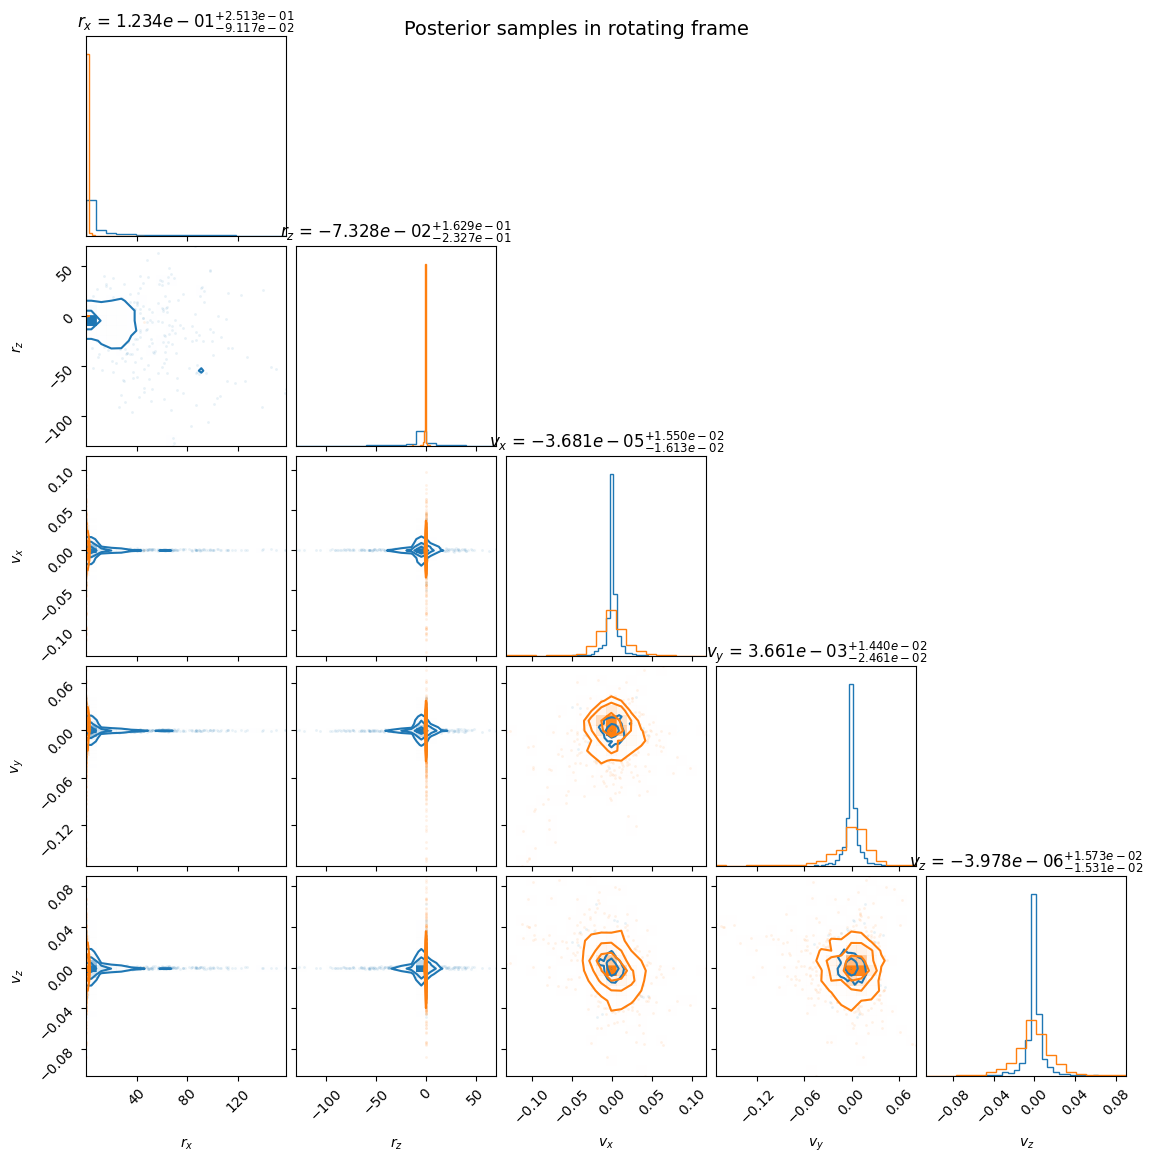

In [14]:
fig = corner.corner(
    samples_correct,
    labels=[r"$r_x$", r"$r_z$", r"$v_x$", r"$v_y$", r"$v_z$"],
    show_titles=True,hist_kwargs={"density":True},
    title_fmt=".3e",
    color="C0",
)

corner.corner(
    samples,fig=fig,
    labels=[r"$r_x$", r"$r_z$", r"$v_x$", r"$v_y$", r"$v_z$"],
    show_titles=True,hist_kwargs={"density":True},
    title_fmt=".3e",
    color="C1",
)


fig.suptitle("Posterior samples in rotating frame", fontsize=14)
plt.show()

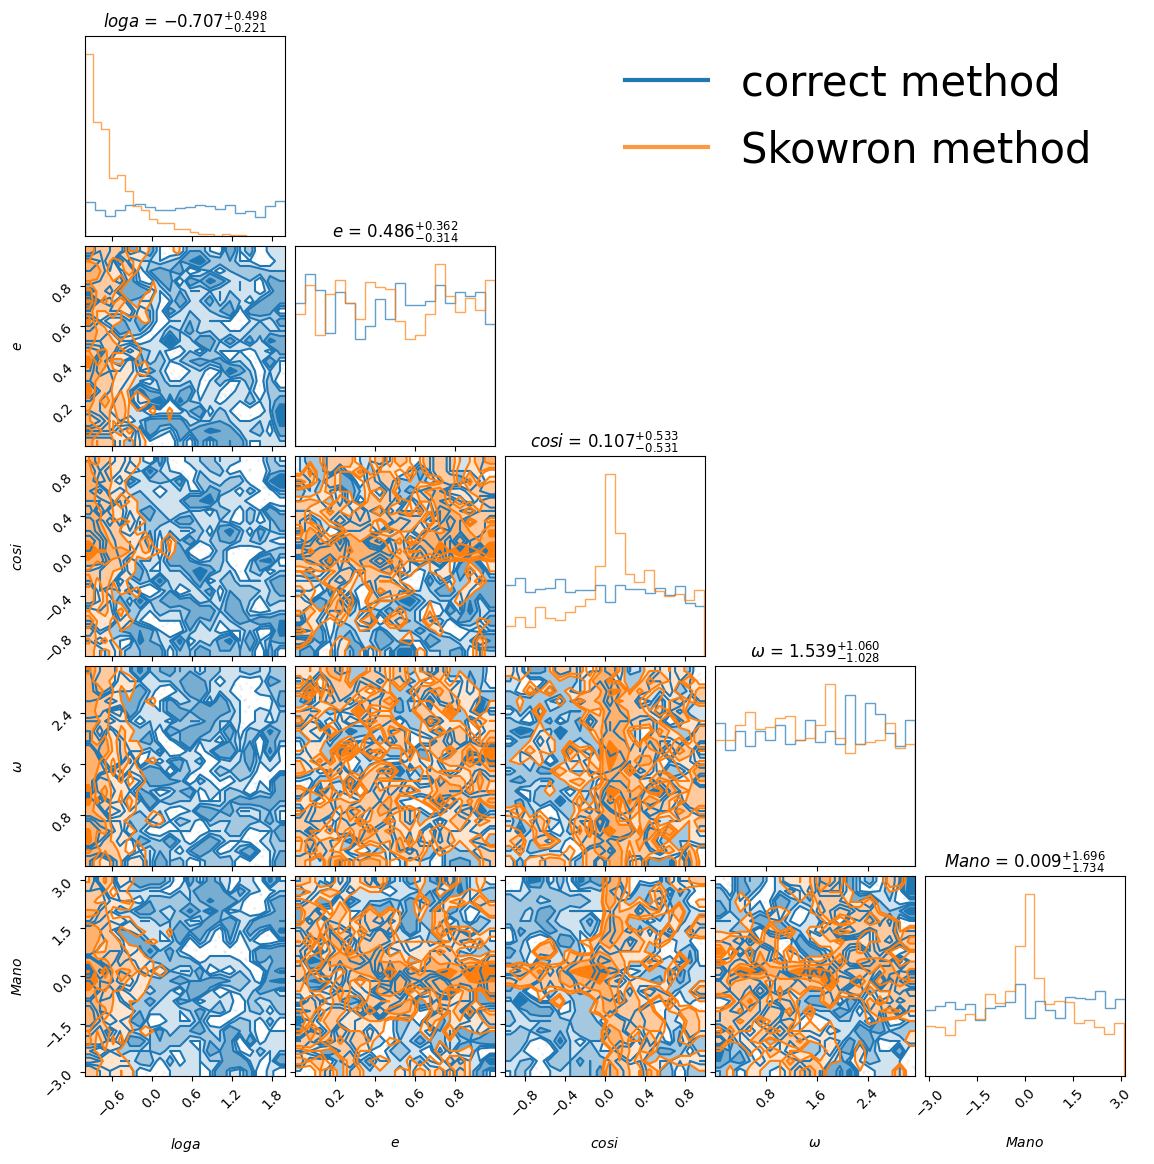

In [25]:
kepler = jax.vmap(rv_to_kepler_rot)(
    samples[:, 0],  # rx
    samples[:, 1],  # rz
    samples[:, 2],  # vx
    samples[:, 3],  # vy
    samples[:, 4],  # vz
)

loga, e, cosi,  om, Mano = kepler.T

df_kep = pd.DataFrame({
    "loga": loga,
    "e": e,
    "cosi": cosi,
    "ω": om,
    "Mano": Mano
})

kepler_correct = jax.vmap(rv_to_kepler_rot)(
    samples_correct[:, 0],  # rx
    samples_correct[:, 1],  # rz
    samples_correct[:, 2],  # vx
    samples_correct[:, 3],  # vy
    samples_correct[:, 4],  # vz
)

loga_correct, e_correct, cosi_correct, om_correct, Mano_correct = kepler_correct.T

df_kep_correct = pd.DataFrame({
    "loga": loga_correct,
    "e": e_correct,
    "cosi": cosi_correct,
    "ω": om_correct,
    "Mano": Mano_correct
})

# --- コーナープロット ---
fig = corner.corner(
    df_kep_correct[["loga", "e", "cosi", "ω", "Mano"]],
    labels=[r"$loga$", r"$e$", r"$cosi$", r"$\omega$", r"$Mano$"],
    show_titles=True,
    title_fmt=".3f",
    color="C0",
    hist_kwargs=dict(density=True, alpha=0.7),
    plot_datapoints=True,
    fill_contours=True,
)

corner.corner(
    df_kep[["loga", "e", "cosi", "ω", "Mano"]],fig=fig,
    labels=[r"$loga$", r"$e$", r"$cosi$", r"$\omega$", r"$Mano$"],
    show_titles=True,
    title_fmt=".3f",
    color="C1",
    hist_kwargs=dict(density=True, alpha=0.7),
    plot_datapoints=True,
    fill_contours=True,
)

legend_handles = [
        Line2D([0], [0], color="C0", lw=3, label=r"correct method"),
        Line2D([0], [0], color="C1", lw=3, alpha=0.8, label=r"Skowron method"),
]


fig.legend(
    handles=legend_handles,
    loc="upper right",
    fontsize=30,
    frameon=False,
    borderpad=1,
    labelspacing=0.6
) 

plt.savefig("../test_figures/comp_skowron.png",dpi=300)

plt.show()

In [27]:
key = jax.random.PRNGKey(45)
key, k_a, k_e, k_i, k_Om, k_om, k_M = jax.random.split(key, 7)
N = 20000

log_a = jax.random.uniform(k_a, (N,), minval=jnp.log(0.1), maxval=jnp.log(100))
a = jnp.exp(log_a)
e = jax.random.uniform(k_e, (N,), minval=0.0, maxval=0.99) 
cosi = jax.random.uniform(k_i, (N,), minval=-1, maxval=1)
i = jnp.arccos(cosi)
Om = jax.random.uniform(k_Om, (N,), minval=0.0, maxval=2*jnp.pi)
om = jax.random.uniform(k_om, (N,), minval=0.0, maxval=2*jnp.pi)
M = jax.random.uniform(k_M, (N,), minval=-jnp.pi, maxval=jnp.pi)
n = jnp.sqrt(mu / a**3)
t_peri = tref - M / n

rv_rot = jax.vmap(kepler_to_rv_rotating_frame)(a, e, i, om, t_peri)
r_x = rv_rot[:, 0]

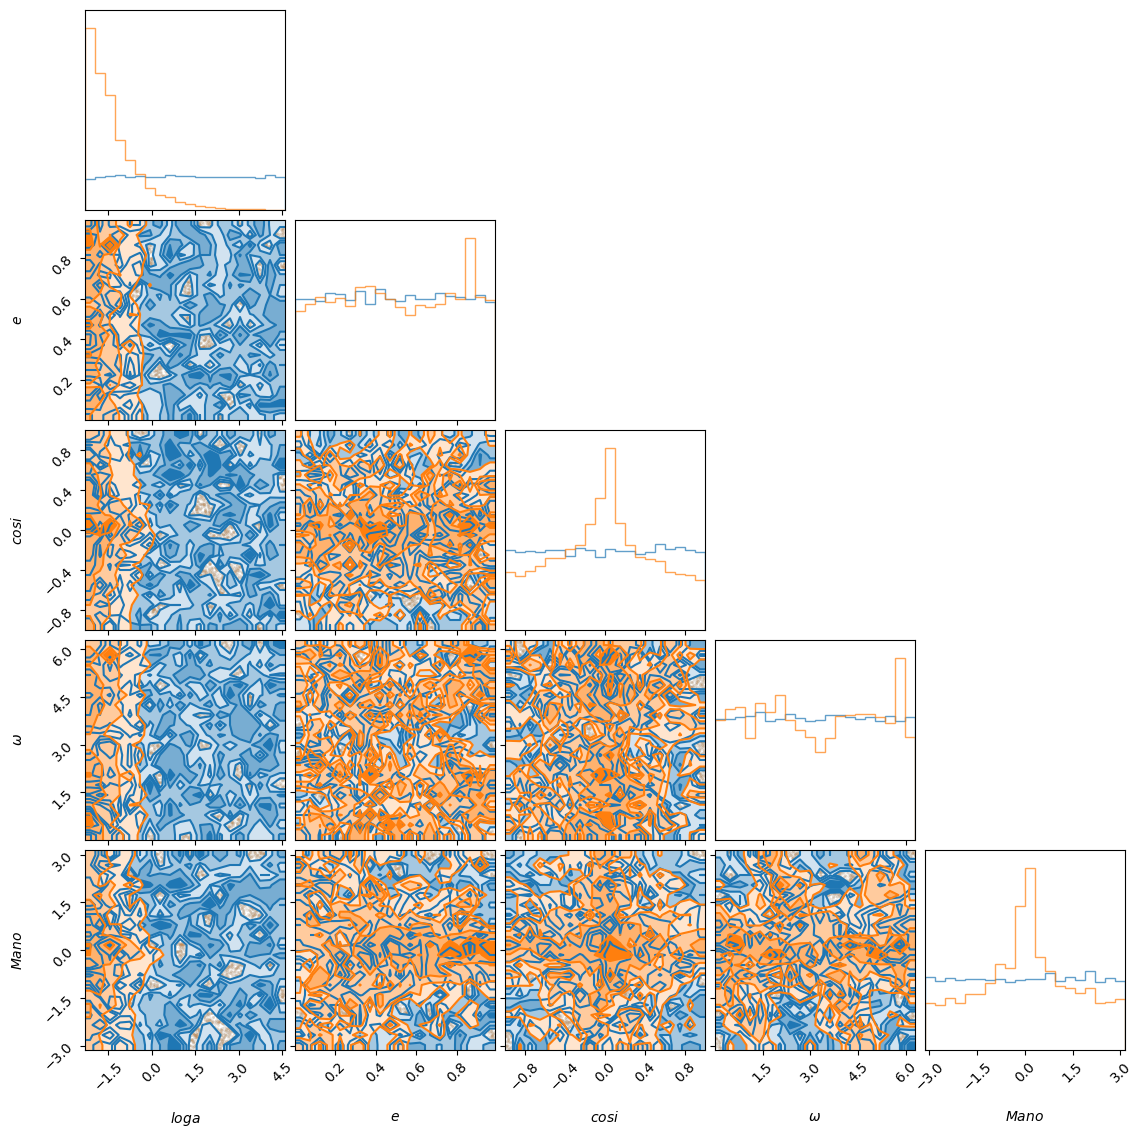

In [32]:
data = np.vstack([log_a, e, cosi, om, M]).T

fig = corner.corner(data,hist_kwargs=dict(density=True, alpha=0.7),color="C0",
    plot_datapoints=True,
    fill_contours=True,)
corner.corner(data,weights=1/r_x,fig=fig,color="C1",hist_kwargs=dict(density=True, alpha=0.7),
    labels=[r"$loga$", r"$e$", r"$cosi$", r"$\omega$", r"$Mano$"],
    plot_datapoints=True,
    fill_contours=True,)

plt.show()